In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# step response

df_track = pd.read_csv("/content/drive/MyDrive/advanced_mech2/lab 3/Lab_3.5_ref_measurement_300_100.csv")
df_ce = pd.read_csv("/content/drive/MyDrive/advanced_mech2/lab 3/Lab_3.5_control_effort_300_100.csv")
df_step = pd.read_csv('/content/drive/MyDrive/advanced_mech2/lab 3/Lab_3.4_Step_Response.csv')




In [ ]:
time_track = np.array(df_track['Time - Plot 1'])
time_step = np.array(df_step['Time - Plot 1'])
amp = np.array(df_step['Amplitude - Plot 1'])
square_input = np.array(df_step['Amplitude - Plot 0'])
ref = np.array(df_track['Amplitude - Plot 1'])
meas = np.array(df_track['Amplitude - Plot 0'])
error = ref - meas 
ce = np.array(df_ce['Amplitude - Plot 0'])

In [ ]:
time_track[30]

30

In [ ]:
time_step[1300]

3328884

In [ ]:
time_track = (time_track[30:]-30)*0.0005
ref = ref[30:]
meas = meas[30:]
error = error[30:]
ce = ce[30:]

In [ ]:
time_track[0]

0.0

In [ ]:
time_step = (time_step[1300:2000]-3328884)*0.0005
amp = amp[1300:2000]
square_input = square_input[1300:2000]

In [ ]:
time_step[0]


0.0

In [ ]:
tau_line_x = np.arange(min(time), max(time)+0.001, 0.001)
tau_line_y = np.ones(tau_line_x.size) * (1-math.exp(-1))

NameError: ignored

In [ ]:
tau_line_y

NameError: ignored

In [ ]:
print(tau_line_y.size)
print(amp.size)

NameError: ignored

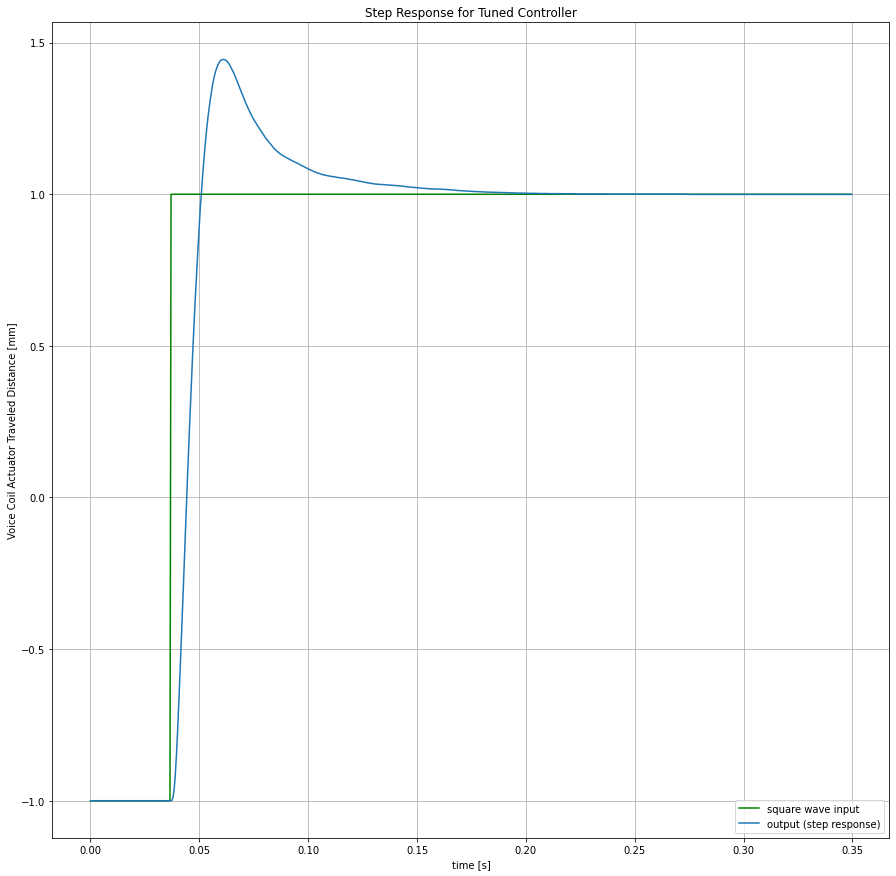

In [ ]:
fig_step = plt.figure(figsize = (15,15))
plt.xlabel('time [s]')
plt.ylabel('Voice Coil Actuator Traveled Distance [mm]')
plt.title('Step Response for Tuned Controller')
#plt.xticks(np.arange(min(time), max(time)+0.01, 0.05))

plt.plot(time_step,square_input,'g-', label = 'square wave input')
plt.plot(time_step,amp, label = 'output (step response)')

#idx = np.argwhere(np.diff(np.sign(amp - tau_line_y))).flatten()
plt.grid()
#plt.plot(time[idx[0]], amp[idx[0]], 'rx', markersize = '10', label = 'time constant location')
plt.legend(loc = 'lower right')
plt.show()


# excuse the inaccuracy of the plot. The first dot looks okay and is the easiest estimate of the time constant








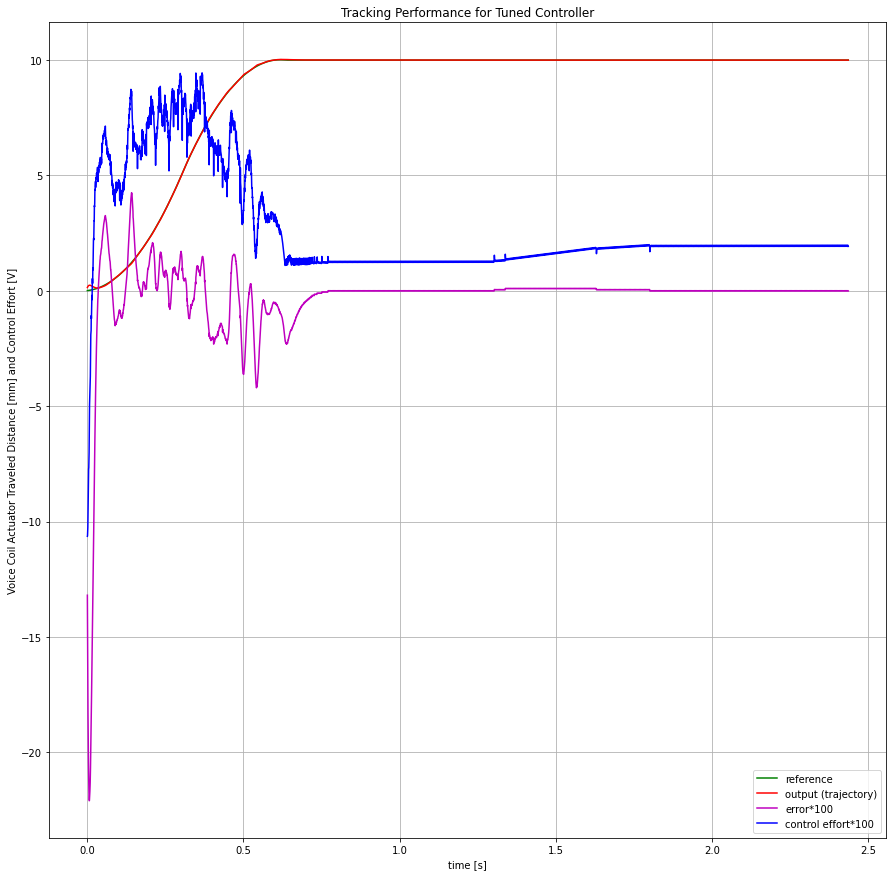

In [ ]:
fig_step = plt.figure(figsize = (15,15))
plt.xlabel('time [s]')
plt.ylabel('Voice Coil Actuator Traveled Distance [mm] and Control Effort [V]')
plt.title('Tracking Performance for Tuned Controller')
#plt.xticks(np.arange(min(time), max(time)+0.01, 0.05))

plt.plot(time_track,ref,'g-', label = 'reference')
plt.plot(time_track,meas,'r-', label = 'output (trajectory)')
plt.plot(time_track,error*100,'m-', label = 'error*100')
plt.plot(time_track,ce*100,'b-', label = 'control effort*100')


#idx = np.argwhere(np.diff(np.sign(amp - tau_line_y))).flatten()
plt.grid()
#plt.plot(time[idx[0]], amp[idx[0]], 'rx', markersize = '10', label = 'time constant location')
plt.legend(loc = 'lower right')
plt.show()

In [ ]:
tau_idx = idx[0]
print('idx of tau_measured:',tau_idx)

tau_measured = time[tau_idx]
print('measured time constant:', tau_measured)

idx of tau_measured: 22
measured time constant: 0.022


In [ ]:
# truncate rest of data
amp_2 = amp[0:tau_idx+1]

zero_time_val =  time[np.absolute(amp_2).argmin()]
print(zero_time_val)
tau_measured_corrected = tau_measured - zero_time_val

0.011


In [ ]:
df4= pd.read_csv("manitude_double_intergrator_plant.csv")
df1 = pd.read_csv("phase_double_intergrator_plant.csv")